# Correlated-noise OU (coupled 2-field, φ⁴) — a nonzero cross-correlator

**Showcases:** correlated / off-diagonal white noise in a coupled 2-field Ornstein–Uhlenbeck system. The two fields $x,y$ are each driven by their own white noise, but the two noises are **cross-correlated** (coefficient $\rho$). That off-diagonal noise routes through the coupled MSR-JD path and produces a **nonzero cross-correlator** $C_{xy}(\tau)=\langle x(0)\,y(\tau)\rangle$ — the headline observable here. Run to **1-loop**, the quartic vertex's self-energy lowers the linear (tree) value toward the simulation.

$$\dot x = -\mu_1 x - \varepsilon_1 x^3 + J_1 y + \xi_x,\qquad \dot y = -\mu_2 y - \varepsilon_2 y^3 + J_2 x + \xi_y,$$
$$\langle \xi_\alpha(t)\,\xi_\beta(t')\rangle = 2\,C_{\alpha\beta}\,\delta(t-t'),\qquad C = \begin{pmatrix} D_1 & \rho\sqrt{D_1 D_2} \\ \rho\sqrt{D_1 D_2} & D_2 \end{pmatrix}.$$

## 0. Setup

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for models/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure straight from the theory file — domain, fields, parameters, the off-diagonal noise block, and the governing equations. The fluctuation fields are `dx`, `dy`.

In [2]:
model, mod = dd.load_theory('ou_quartic_two_dim_corr')
dd.describe_model(model, mod)
print('\nfield names:', dd.field_names(model))

────────────────────────────────────────────────────────────────────────
  OU Quartic Two Dim Corr
────────────────────────────────────────────────────────────────────────
Domain         : temporal ODE (time-only)
Fields         : x — variable1; y — variable2
Response fields: xt, yt
Parameters     :
    mu1 = 1.0  (real)
    mu2 = 1.0  (real)
    eps1 = 0.05  (positive)
    eps2 = 0.05  (positive)
    J1 = 0.5  (real)
    J2 = 0.5  (real)
    D1 = 1.0  (positive)
    D2 = 1.0  (positive)
    rho = 0.5  (real)
    tauc = 10.0  (positive)
Mean-field saddle (solved by the pipeline): xstar, ystar
Governing eqn  : (Dt+mu1)*x = -eps1*x^3 + J1*y
Governing eqn  : (Dt+mu2)*y = -eps2*y^3 + J2*x
Suggested run  : k=2, max_ell=0

field names: ['dx', 'dy']


## 2. The pipeline → theoretical cumulants

One `dd.run` drives the whole MSR-JD chain (enumerate diagrams → coupled propagator → mean-field saddle → loop integrals → cumulant). We pick the **cross**-correlator legs `[('dx', 1), ('dy', 1)]`, so the only thing that can make $C_{xy}$ nonzero is the off-diagonal noise (plus the $J$ cross-coupling). The plot is the **theory only** — tree (linear/LNA) and tree+1-loop; the simulation is added in §3.

In [3]:
# Symmetric, sub-critical, weakly-nonlinear regime.  rho=0.5 is the noise
# cross-correlation; J1=J2=0.5 the drift cross-coupling.  Origin is the
# single stable saddle (mu1*mu2 - J1*J2 = 0.75 > 0), so the linear (tree)
# correlator is the LNA prediction and the 1-loop is the quartic shift.
fund = dict(mu1=1.0, mu2=1.0, eps1=0.02, eps2=0.02,
            J1=0.5, J2=0.5, D1=1.0, D2=1.0, rho=0.5)
cfg = dd.Config(
    k=2, max_ell=1,                          # cross-cumulant ⟨x y⟩, tree + 1-loop
    external_fields=[('dx', 1), ('dy', 1)],  # ← the CROSS legs (headline)
    parameters=fund,
    tau_max=6.0, tau_step=0.5,
    parallel=False,                          # serial (no fork on macOS)
)

# ── more dd.Config knobs you can add (commented; `dd.config_options()` prints all) ──
#   max_ell=1,                      # loop order: 0=tree · 1=+1-loop · 2=+2-loop
#   output='moment',                # 'cumulant' (default) | 'moment' | 'central_moment'
#   tau_max=20.0, tau_step=0.5,     # τ (lag) grid for C(τ)  ·  or tau_grid=(-20,20,81)
#   show_orders='incremental',      # 'cumulative' (default) | 'incremental' | 'total'
#   logy=True, title='…', save='fig.png',
#   parallel=True, n_workers=4,     # parallel batch (n_workers bites outside Jupyter on macOS)
#   fixed_point_index=0,            # multi-root saddle: which stable root to expand around
# For k≥3 the cumulant is a function of k−1 lags τ_j = t_j − t_0:
#   kpoint_base_lags=[0.0, 0.0],    # fix the non-swept legs (the axis slices cross here)
#   kpoint_full_grid=True,          # full (k−1)-D tensor C(τ₁,…) instead of the axis slices

theory : 'OU Quartic Two Dim Corr'
k      : 2    max_ell : 1
fields : ['dx', 'dy']   spatial_dim : 0

C_xy(0)  tree (linear/LNA) = +1.3333
C_xy(0)  tree + 1-loop      = +1.0444


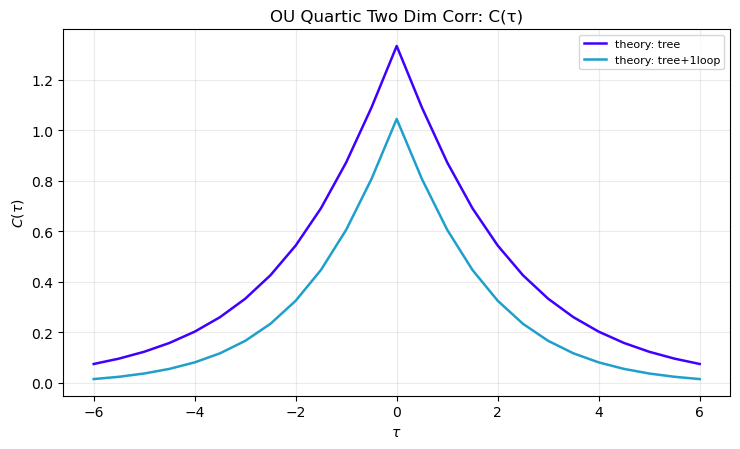

In [4]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))
mid = len(res['tau_grid']) // 2
by = res['C_tau_by_ell']
print('\nC_xy(0)  tree (linear/LNA) = %+.4f' % np.real(by[0])[mid])
print('C_xy(0)  tree + 1-loop      = %+.4f' % np.real(res['C_tau'])[mid])
dd.plot_cumulant(res, cfg, model)   # theory only
plt.show()

## 3. Independent simulation

A direct Euler–Maruyama integration of the coupled SDE — written from scratch, no reference to the diagrammatics. The two noise increments are drawn from the **correlated** Gaussian (Cholesky of $C$), so the sim carries the same off-diagonal noise the theory does. We estimate the **same two legs** ($x$ then $y$) and overlay the connected $C_{xy}(\tau)$.

simulation: 3 runs x T=6e+05, 7.3s
C_xy(0)  theory tree        = +1.3333
C_xy(0)  theory tree+1-loop = +1.0444
C_xy(0)  simulation         = +1.1216  (+/- 0.0019)


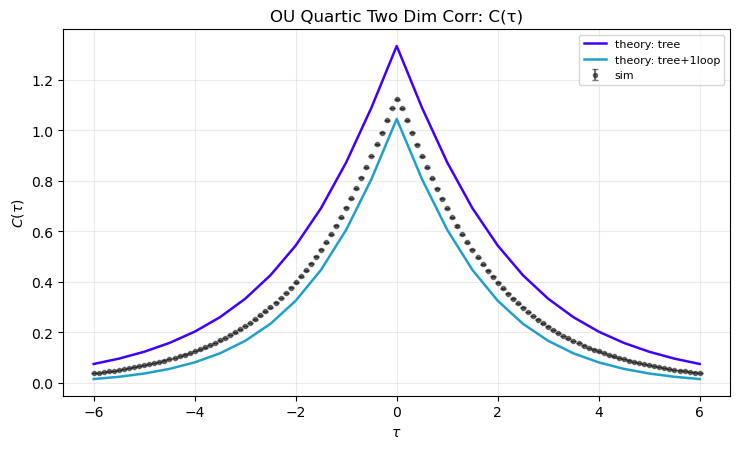

In [5]:
# Independent coupled-SDE simulation (correlated-noise Euler–Maruyama).
from models.ou_langevin_sim_numba import sim_ou_quartic_two_dim_corr_numba
from models.cumulant_estimator import estimate_kpoint_slices
# float()/int() everywhere: under the Sage kernel the dict values and
# literals are Sage Real/Integer types, which numba's nopython mode rejects.
fp = res['_resolved']['parameters']
m1, m2 = float(fp['mu1']),  float(fp['mu2'])
e1, e2 = float(fp['eps1']), float(fp['eps2'])
J1, J2 = float(fp['J1']),   float(fp['J2'])
D1, D2 = float(fp['D1']),   float(fp['D2'])
rho    = float(fp['rho'])

# Fast MC budget (~10s): short runs, small bin so the binned C(0) ≈ the
# instantaneous variance.  The two correlated drivers come from the
# Cholesky of C inside sim_ou_quartic_two_dim_corr_numba.
dt_sim, dt_bin, T_sim, N_RUNS = 0.02, 0.1, 6e5, 3
bss = max(int(round(dt_bin / dt_sim)), 1)
dt_bin_eff = bss * dt_sim
n_steps = int(T_sim / dt_sim);  n_bins = n_steps // bss
max_lag_bins = int(cfg.tau_max / dt_bin_eff)

# k-aware estimator: estimate the k−1 cumulant slices for ANY k.  The legs
# come from the resolved external_fields; each leg's field name maps to its
# simulator row (dx → row 0, dy → row 1 — the two columns of the sim output),
# both voltage-type 'dv'.  For the default k=2 cross-correlator this is the
# single slice ⟨x(0) y(τ)⟩, so the overlay looks exactly as before.
k    = int(res['_resolved']['k'])
ext  = res['_resolved']['external_fields']            # length k, e.g. [('dx',1),('dy',1)]
row_of = {'dx': 0, 'dy': 1}
pop_indices = [row_of[e[0]] for e in ext]             # length k
field_types = ['dv'] * k
base = list(cfg.kpoint_base_lags) if cfg.kpoint_base_lags else [0.0] * (k - 1)
base_bins = [int(round(b / dt_bin_eff)) for b in base]

x0 = y0 = 0.0                                          # start at the saddle
_ = sim_ou_quartic_two_dim_corr_numba(int(1000), float(dt_sim), m1, m2,
        e1, e2, J1, J2, D1, D2, rho, float(x0), float(y0),
        int(bss), int(100), int(0))                    # JIT warmup

t0 = time.perf_counter()
C_runs = []
for r in range(N_RUNS):
    # xy_bins: (2, n_bins) array whose rows 0,1 are the binned x and y traces.
    xy_bins = sim_ou_quartic_two_dim_corr_numba(int(n_steps), float(dt_sim),
            m1, m2, e1, e2, J1, J2, D1, D2, rho, float(x0), float(y0),
            int(bss), int(n_bins), int(1000 + r))
    tau_sim, Cj = estimate_kpoint_slices(
        dt_bin_eff, pop_indices, field_types, base_bins, max_lag_bins,
        voltage_bins=xy_bins)                          # Cj shape (k-1, n_tau)
    C_runs.append(np.asarray(Cj))
C_arr = np.array(C_runs)
C_sim = C_arr.mean(axis=0); C_err = C_arr.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
sim   = {'tau': tau_sim, 'C': C_sim, 'C_err': C_err}   # 2-D: one row per slice

mid = len(res['tau_grid']) // 2
s0 = C_sim.shape[1] // 2
print('simulation: %d runs x T=%.0g, %.1fs' % (N_RUNS, T_sim, time.perf_counter() - t0))
print('C_xy(0)  theory tree        = %+.4f' % np.real(res['C_tau_by_ell'][0])[mid])
print('C_xy(0)  theory tree+1-loop = %+.4f' % np.real(res['C_tau'])[mid])
print('C_xy(0)  simulation         = %+.4f  (+/- %.4f)' % (C_sim[0][s0], C_err[0][s0]))
dd.plot_cumulant(res, cfg, model, sim=sim)
plt.show()

## Summary

The off-diagonal entry of the noise matrix $C$ is the whole story: it routes through the coupled propagator and gives a sizeable **cross-correlator** $C_{xy}(\tau)$ where two *uncorrelated* noises would give (nearly) zero. At these parameters the cross-correlation coefficient at $\tau=0$ is $\approx 0.79$. The **tree** curve is the linear (LNA) cross-correlator; the **1-loop** quartic self-energy lowers it toward the independent simulation, which the overlay confirms. Switch `external_fields` to `[('dx', 1), ('dx', 1)]` for the auto-correlator $C_{xx}$ — the same correlated-noise routing, now on a single field.